In [1]:
import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching
import CircuitBuilder as cb
import CircuitPresets as cp
from tqdm import tqdm

In [11]:
def get_logical_error(circuit, nshots=1000000, batch_size=100000):
    ds = circuit.compile_detector_sampler()
    total_errors = 0
    total_shots = 0
    model = circuit.detector_error_model(decompose_errors=True)
    matching = pymatching.Matching.from_detector_error_model(model)

    shots_remaining = nshots
    while shots_remaining > 0:
        current_batch_size = int(min(batch_size, shots_remaining))
        D, L = ds.sample(current_batch_size, separate_observables=True)
        pred = matching.decode_batch(D)
        total_errors += np.sum(pred[:, 0] != L[:, 0])
        total_shots += current_batch_size
        shots_remaining -= current_batch_size

    return total_errors / total_shots

In [3]:
get_logical_error(cp.build_shor(0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 1))

np.float64(0.0338)

In [8]:
print(min(100 / 0.002, 1000000))

50000.0


In [ ]:
noise_ps = [0.00001, 0.00002, 0.00005, 0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01]
noise_rounds = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
shor_logical_errors_rates = np.zeros((len(noise_ps), len(noise_rounds)))
bacon_logical_errors_rates = np.zeros((len(noise_ps), len(noise_rounds)))

numerator = 100

for i, noise_p in enumerate(noise_ps):
    for j, noise_round in enumerate(tqdm(noise_rounds)):
        shor_logical_errors_rates[i, j] = get_logical_error(cp.build_shor(noise_p, noise_p, noise_p, noise_p, noise_p, noise_p, noise_round), nshots = int(min(numerator / noise_p, 1000000)))
        bacon_logical_errors_rates[i, j] = get_logical_error(cp.build_bacon_z(noise_p, noise_p, noise_p, noise_p, noise_p, noise_p, noise_round), nshots = int(min(numerator / noise_p, 1000000)))


100%|██████████| 10/10 [00:10<00:00,  1.04s/it]


In [45]:
def error_rate_unprotected_qubit(noise_p, noise_round):
    return 0.5 - (1 - 2 * noise_p) ** noise_round / 2

In [46]:
[error_rate_unprotected_qubit(noise_p, noise_round) for noise_round in noise_rounds[1:]]

[0.01980000000000004,
 0.04803960160000004,
 0.09146359655622666,
 0.16619601412245288,
 0.3179151599564416,
 0.43369022205262353,
 0.49120602669713925,
 0.49997948800742725,
 0.49999999915851634]

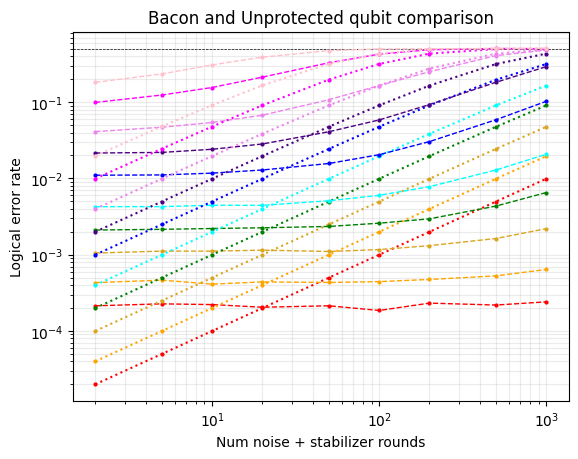

In [93]:
colors = ['red', 'orange', 'goldenrod', 'green', 'cyan', 'blue', 'indigo', 'violet', 'magenta', 'pink']

plt.axhline(y = 0.5, color = 'black', linestyle = '--', linewidth = 0.5)

for i, noise_p in enumerate(noise_ps):
    #plt.plot(noise_rounds[1:], shor_logical_errors_rates[i,:][1:], marker='o', markersize = 2, linewidth = 1, linestyle='-', label = f'{noise_p}', color = colors[i])
    plt.plot(noise_rounds[1:], bacon_logical_errors_rates[i,:][1:], marker='o', markersize = 2, linewidth = 1, linestyle='--', color = colors[i])
    plt.plot(noise_rounds[1:], [error_rate_unprotected_qubit(noise_p, noise_round) for noise_round in noise_rounds[1:]], marker='o', markersize = 2, linestyle=':', color = colors[i])


plt.yscale('log')
plt.xscale('log')
#plt.xlim(0, 0.1)
#plt.ylim(1, 2)
#handles, labels = plt.gca().get_legend_handles_labels()
#plt.legend(handles[::-1], labels[::-1])
plt.xlabel('Num noise + stabilizer rounds')
plt.ylabel('Logical error rate')
plt.title('Bacon and Unprotected qubit comparison')
plt.grid(which='both', alpha = 0.25)
plt.show()


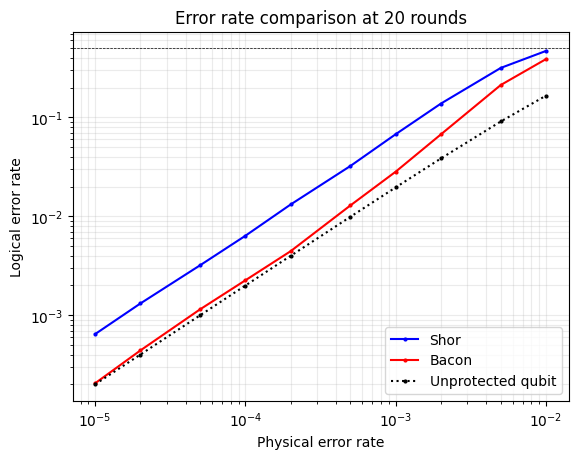

In [99]:
colors = ['red', 'orange', 'goldenrod', 'green', 'cyan', 'blue', 'indigo', 'violet', 'magenta', 'pink']

plt.axhline(y = 0.5, color = 'black', linestyle = '--', linewidth = 0.5)

n = 4
plt.plot(noise_ps, shor_logical_errors_rates[:,n], 'o', markersize = 2, linestyle = '-', color = 'blue', label = 'Shor')
plt.plot(noise_ps, bacon_logical_errors_rates[:,n], 'o', markersize = 2, linestyle = '-', color = 'red', label = 'Bacon')
plt.plot(noise_ps, [error_rate_unprotected_qubit(noise_p, noise_rounds[n]) for noise_p in noise_ps], 'o', markersize = 2, linestyle = ':', color = 'black', label = 'Unprotected qubit')

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Physical error rate')
plt.ylabel('Logical error rate')
plt.title(f'Error rate comparison at {noise_rounds[n]} rounds')

plt.grid(which='both', alpha = 0.25)
plt.legend()
plt.show()


In [18]:
print(shor_logical_errors_rates[1])

[0.000732 0.001307 0.001245 0.00132  0.001314 0.001239 0.001228 0.001294
 0.001344 0.001432]


In [109]:
lastbacon = cp.build_bacon_z(0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 1000)
lastbacon

stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8
    X_ERROR(0.01) 0 1 2 3 4 5 6 7 8
    R 9 10 11 12 13 14 15 16 17 18 19 20
    X_ERROR(0.01) 9 10 11 12 13 14 15 16 17 18 19 20
    CX 0 9 1 10 3 11 4 12 6 13 7 14
    DEPOLARIZE2(0.01) 0 9 1 10 3 11 4 12 6 13 7 14
    CX 1 9 2 10 4 11 5 12 7 13 8 14
    DEPOLARIZE2(0.01) 1 9 2 10 4 11 5 12 7 13 8 14
    MR(0.01) 9 10 11 12 13 14
    X_ERROR(0.01) 9 10 11 12 13 14
    H 15 16 17 18 19 20
    DEPOLARIZE1(0.01) 15 16 17 18 19 20
    CX 15 0 16 3 17 1 18 4 19 2 20 5
    DEPOLARIZE2(0.01) 15 0 16 3 17 1 18 4 19 2 20 5
    CX 15 3 16 6 17 4 18 7 19 5 20 8
    DEPOLARIZE2(0.01) 15 3 16 6 17 4 18 7 19 5 20 8
    H 15 16 17 18 19 20
    DEPOLARIZE1(0.01) 15 16 17 18 19 20
    MR(0.01) 15 16 17 18 19 20
    X_ERROR(0.01) 15 16 17 18 19 20
    REPEAT 1000 {
        TICK
        DEPOLARIZE1(0.01) 0 1 2 3 4 5 6 7 8
        CX 0 9 1 10 3 11 4 12 6 13 7 14
        DEPOLARIZE2(0.01) 0 9 1 10 3 11 4 12 6 13 7 14
        CX 1 9 2 10 4 11 5 12 7 13 8 14
       